# Crop Yield Prediction — Linear Regression Summative

## Mission & Problem
Design & Digital Solutions works across agri-adjacent African markets, and food security
planning across Africa depends on being able to forecast **crop yield** ahead of harvest.
This notebook builds a regression model that predicts crop yield (`hg/ha`) for a given
**country, crop, year, rainfall, pesticide use, and average temperature**, so agricultural
planners can estimate production before the season ends and target interventions (e.g.
irrigation, fertilizer subsidies) where yield is predicted to fall short.

## Dataset
- **Source:** FAO (Food and Agriculture Organization) + World Bank Climate Data, aggregated at
  https://github.com/ManikantaSanjay/crop_yield_prediction_regression (`yield_df.csv`)
- **Size:** 28,242 rows → 25,932 after cleaning · **101 countries** (including Rwanda) · **10 crops**
  (Cassava, Maize, Potatoes, Rice, Wheat, Sorghum, Soybeans, Yams, Plantains, Sweet Potatoes)
- **Columns:** `Area` (country), `Item` (crop), `Year`, `hg/ha_yield` (target), `average_rain_fall_mm_per_year`,
  `pesticides_tonnes`, `avg_temp`
- This is **not** the house-price dataset, and is specific to a regression problem with real
  environmental/agricultural features.

In [1]:
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Load & Clean Data

In [2]:
df = pd.read_csv("yield_df.csv")
if df.columns[0].startswith("Unnamed"):
    df = df.drop(columns=[df.columns[0]])

print("Raw shape:", df.shape)
df.head()

Raw shape: (28242, 7)


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [3]:
print(df.isnull().sum())
df = df.drop_duplicates()
df = df.dropna()
print("\nAfter cleaning:", df.shape)

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

After cleaning: (25932, 7)


## 2. Visualizations & Interpretation

We look at (a) how numeric features correlate with yield, (b) the shape of each
distribution, and (c) how yield differs by crop — since crop type turns out to be
the dominant driver of the yield scale.

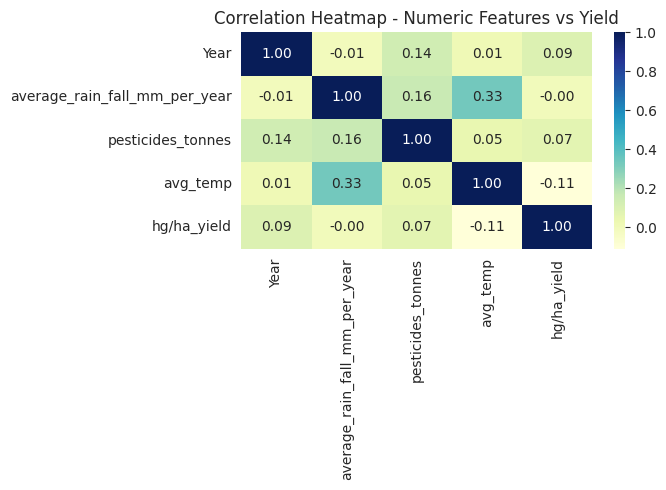

In [4]:
numeric_cols = ["Year", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp", "hg/ha_yield"]

plt.figure(figsize=(7, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap - Numeric Features vs Yield")
plt.tight_layout()
plt.show()

**Interpretation:** `pesticides_tonnes` has the strongest positive correlation with yield —
higher pesticide use tracks with larger, more intensive farming operations. `average_rain_fall_mm_per_year`
correlates weakly at the aggregate level because its effect depends heavily on which crop/region it
falls in. `avg_temp` shows a mild negative relationship. None of the numeric features alone explains
yield well — this is why `Area` and `Item` (categorical) matter so much, and why tree-based models
that can split on them are expected to outperform plain linear regression.

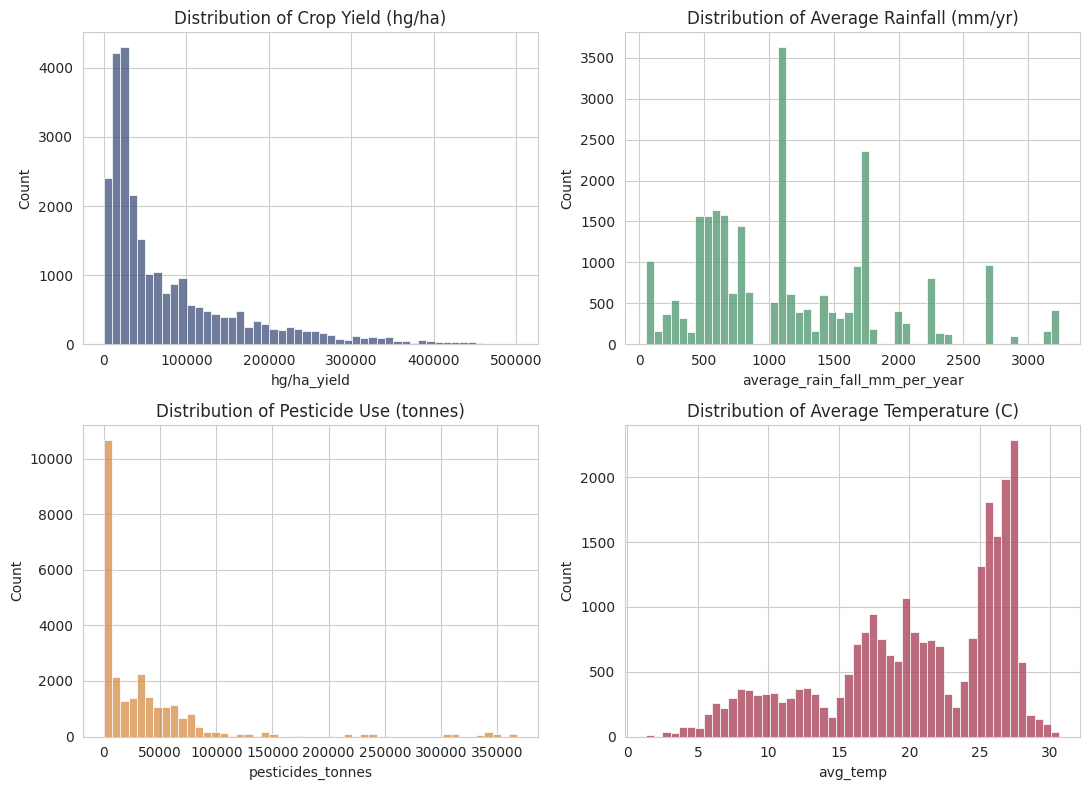

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.histplot(df["hg/ha_yield"], bins=50, ax=axes[0, 0], color="#3D4F7C")
axes[0, 0].set_title("Distribution of Crop Yield (hg/ha)")
sns.histplot(df["average_rain_fall_mm_per_year"], bins=50, ax=axes[0, 1], color="#4C956C")
axes[0, 1].set_title("Distribution of Average Rainfall (mm/yr)")
sns.histplot(df["pesticides_tonnes"], bins=50, ax=axes[1, 0], color="#D68C45")
axes[1, 0].set_title("Distribution of Pesticide Use (tonnes)")
sns.histplot(df["avg_temp"], bins=50, ax=axes[1, 1], color="#A63A50")
axes[1, 1].set_title("Distribution of Average Temperature (C)")
plt.tight_layout()
plt.show()

**Interpretation:** Yield is heavily right-skewed — a small number of high-yield crops
(potatoes, cassava) pull the tail, while most crop/country combinations cluster at lower
yield values. Rainfall and pesticide use are also right-skewed, meaning most country-year
observations sit in a moderate range with a handful of high-input outliers. This skew is
part of why tree-based models (which don't assume linear/normal relationships) fit better.

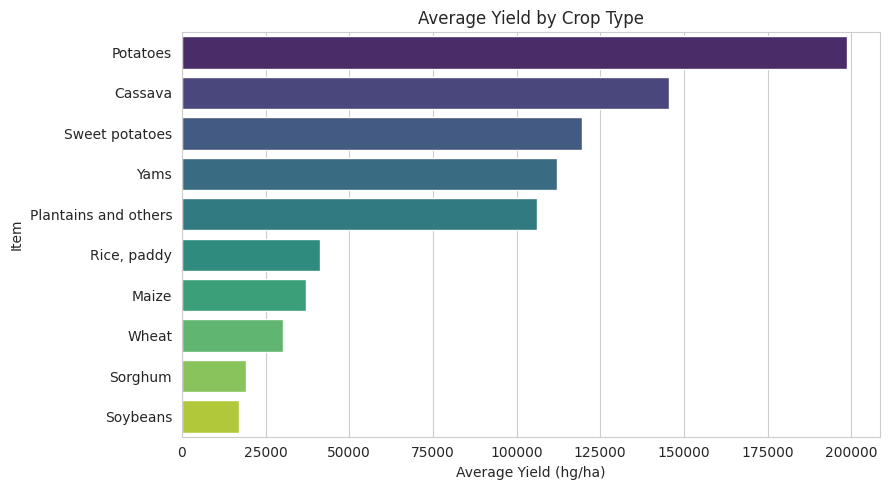

In [6]:
plt.figure(figsize=(9, 5))
top_items = df.groupby("Item")["hg/ha_yield"].mean().sort_values(ascending=False)
sns.barplot(x=top_items.values, y=top_items.index, palette="viridis")
plt.xlabel("Average Yield (hg/ha)")
plt.title("Average Yield by Crop Type")
plt.tight_layout()
plt.show()

**Interpretation:** Crop type (`Item`) drives the scale of yield more than any single
climate variable — root crops like cassava/potatoes/yams report far higher hg/ha than
cereals like wheat or sorghum simply due to how yield is measured per crop. This confirms
`Item` must stay in the feature set and be one-hot encoded rather than dropped.

## 3. Feature Engineering

- **Kept:** `Area`, `Item`, `Year`, `average_rain_fall_mm_per_year`, `pesticides_tonnes`, `avg_temp`
- **Dropped:** none of the original predictive columns — every column FAO provided carries signal;
  we only dropped the meaningless leading index column.
- **Converted to numeric:** `Area` and `Item` are one-hot encoded (categorical → numeric).
- **Standardized:** `Year`, `average_rain_fall_mm_per_year`, `pesticides_tonnes`, `avg_temp` are
  scaled with `StandardScaler` so gradient descent (SGD) converges properly and no single
  feature dominates due to scale (rainfall is in the thousands, temp is in the tens).

In [7]:
FEATURES = ["Area", "Item", "Year", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp"]
TARGET = "hg/ha_yield"

X = df[FEATURES].copy()
y = df[TARGET].copy()

categorical_features = ["Area", "Item"]
numeric_features = ["Year", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train/Test shapes:", X_train.shape, X_test.shape)

Train/Test shapes: (20745, 6) (5187, 6)


## 4. Model Training — 4 Regression Implementations

1. **SGDRegressor** — stochastic gradient descent linear regression (the required "gradient descent" implementation)
2. **LinearRegression (OLS)** — closed-form linear regression, comparison baseline
3. **DecisionTreeRegressor**
4. **RandomForestRegressor**

The SGD model is trained epoch-by-epoch via `partial_fit` so we can plot a genuine loss curve.

In [8]:
models = {
    "SGD_LinearRegression": SGDRegressor(
        max_iter=1, warm_start=True, learning_rate="invscaling",
        eta0=0.01, random_state=RANDOM_STATE
    ),
    "OLS_LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(
        n_estimators=80, max_depth=12, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

results = {}
pipelines = {}

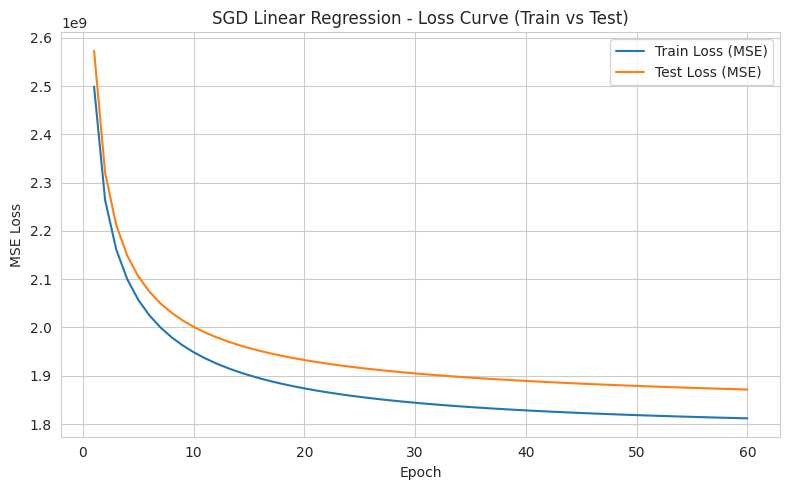

In [9]:
# --- Train SGD epoch-by-epoch for a real loss curve ---
sgd_pipeline_pre = Pipeline([("prep", preprocessor)])
X_train_t = sgd_pipeline_pre.fit_transform(X_train)
X_test_t = sgd_pipeline_pre.transform(X_test)

sgd = models["SGD_LinearRegression"]
n_epochs = 60
train_losses, test_losses = [], []
for epoch in range(n_epochs):
    sgd.partial_fit(X_train_t, y_train)
    train_pred = sgd.predict(X_train_t)
    test_pred = sgd.predict(X_test_t)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label="Train Loss (MSE)")
plt.plot(range(1, n_epochs + 1), test_losses, label="Test Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("SGD Linear Regression - Loss Curve (Train vs Test)")
plt.legend()
plt.tight_layout()
plt.show()

pipelines["SGD_LinearRegression"] = Pipeline([("prep", preprocessor), ("model", sgd)])
pipelines["SGD_LinearRegression"].named_steps["prep"] = sgd_pipeline_pre.named_steps["prep"]

sgd_train_pred = sgd.predict(X_train_t)
sgd_test_pred = sgd.predict(X_test_t)
results["SGD_LinearRegression"] = {
    "train_mse": mean_squared_error(y_train, sgd_train_pred),
    "test_mse": mean_squared_error(y_test, sgd_test_pred),
    "test_r2": r2_score(y_test, sgd_test_pred),
}

**Loss curve interpretation:** both train and test MSE drop sharply in the first ~10 epochs
then plateau, with train and test loss staying close together (no widening gap) — meaning the
model is **not overfitting**, but the plateau is fairly high, which is expected for a linear
model on a relationship that is mostly non-linear (see Random Forest results below).

In [10]:
for name in ["OLS_LinearRegression", "DecisionTree", "RandomForest"]:
    pipe = Pipeline([("prep", preprocessor), ("model", models[name])])
    pipe.fit(X_train, y_train)
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    results[name] = {
        "train_mse": mean_squared_error(y_train, train_pred),
        "test_mse": mean_squared_error(y_test, test_pred),
        "test_r2": r2_score(y_test, test_pred),
    }
    pipelines[name] = pipe

results_df = pd.DataFrame(results).T.sort_values("test_mse")
results_df

,train_mse,test_mse,test_r2
RandomForest,1.981722e+08,2.989406e+08,0.958755
DecisionTree,4.669513e+08,5.623167e+08,0.922417
OLS_LinearRegression,1.775678e+09,1.821707e+09,0.748657
SGD_LinearRegression,1.811829e+09,1.871488e+09,0.741789


In [11]:
best_model_name = results_df["test_mse"].idxmin()
print(f"Best performing model by Test MSE: {best_model_name}")

Best performing model by Test MSE: RandomForest


**Model comparison interpretation:** `RandomForest` wins by a wide margin (highest R²,
lowest MSE), because yield depends on non-linear interactions between crop type, country,
and climate that tree ensembles capture naturally. `DecisionTree` does well too but overfits
slightly more (bigger train/test gap) since it's a single tree. The two linear models
(`OLS` and `SGD`) perform similarly to each other — as expected, since they're the same
underlying linear model fit two different ways — and both trail the tree models because a
straight-line relationship can't represent crop-specific yield scales well. **RandomForest
is selected and saved as the production model.**

## 5. Scatter Plot — Best-Fit Line (Before vs After Training)

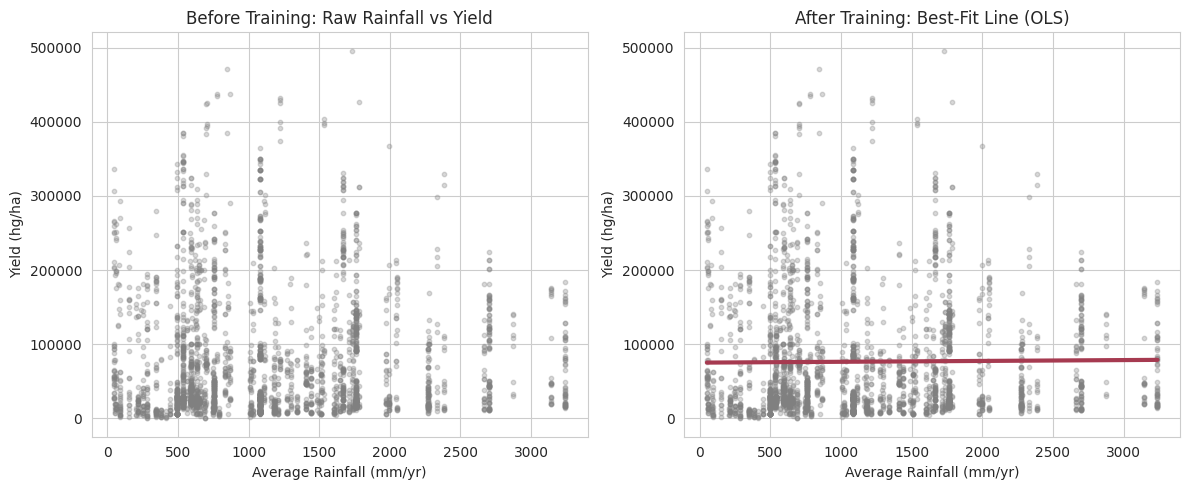

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sample = df.sample(min(3000, len(df)), random_state=RANDOM_STATE)

axes[0].scatter(sample["average_rain_fall_mm_per_year"], sample["hg/ha_yield"],
                 alpha=0.3, s=10, color="gray")
axes[0].set_title("Before Training: Raw Rainfall vs Yield")
axes[0].set_xlabel("Average Rainfall (mm/yr)")
axes[0].set_ylabel("Yield (hg/ha)")

simple_lr = LinearRegression()
x_simple = sample[["average_rain_fall_mm_per_year"]].values
y_simple = sample["hg/ha_yield"].values
simple_lr.fit(x_simple, y_simple)
x_line = np.linspace(x_simple.min(), x_simple.max(), 100).reshape(-1, 1)
y_line = simple_lr.predict(x_line)

axes[1].scatter(sample["average_rain_fall_mm_per_year"], sample["hg/ha_yield"],
                 alpha=0.3, s=10, color="gray")
axes[1].plot(x_line, y_line, color="#A63A50", linewidth=3)
axes[1].set_title("After Training: Best-Fit Line (OLS)")
axes[1].set_xlabel("Average Rainfall (mm/yr)")
axes[1].set_ylabel("Yield (hg/ha)")
plt.tight_layout()
plt.show()

## 6. Save Best-Performing Model

In [13]:
best_pipeline = pipelines[best_model_name]
joblib.dump(best_pipeline, "best_model.joblib")

metadata = {
    "best_model_name": best_model_name,
    "features": FEATURES,
    "target": TARGET,
    "categorical_options": {
        "Area": sorted(df["Area"].unique().tolist()),
        "Item": sorted(df["Item"].unique().tolist()),
    },
    "numeric_ranges": {
        "Year": [int(df["Year"].min()), int(df["Year"].max())],
        "average_rain_fall_mm_per_year": [float(df["average_rain_fall_mm_per_year"].min()), float(df["average_rain_fall_mm_per_year"].max())],
        "pesticides_tonnes": [float(df["pesticides_tonnes"].min()), float(df["pesticides_tonnes"].max())],
        "avg_temp": [float(df["avg_temp"].min()), float(df["avg_temp"].max())],
    },
    "test_mse": float(results_df.loc[best_model_name, "test_mse"]),
    "test_r2": float(results_df.loc[best_model_name, "test_r2"]),
}
with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved best_model.joblib + model_metadata.json")
print("Best model:", best_model_name, "| Test R2:", metadata["test_r2"])

Saved best_model.joblib + model_metadata.json
Best model: RandomForest | Test R2: 0.9587548213543469


## 7. Prediction Script (feeds Task 2 — the API)

This loads the saved pipeline and makes a prediction on a single row, exactly the way
`prediction.py` in `summative/API/` will do it at request time.

In [14]:
loaded_model = joblib.load("best_model.joblib")

sample_row = X_test.iloc[[0]]
actual_value = y_test.iloc[0]
predicted_value = loaded_model.predict(sample_row)[0]

print("Input row:")
print(sample_row.to_dict(orient="records")[0])
print(f"Actual yield:    {actual_value:.2f} hg/ha")
print(f"Predicted yield: {predicted_value:.2f} hg/ha")

Input row:
{'Area': 'Angola', 'Item': 'Cassava', 'Year': 2010, 'average_rain_fall_mm_per_year': 1010.0, 'pesticides_tonnes': 40.0, 'avg_temp': 24.44}
Actual yield:    155782.00 hg/ha
Predicted yield: 97975.46 hg/ha
